# 회전설비 주요 고장원인과 특징량 요약 + 가상 데이터 분석

이 노트북은 회전설비(모터/펌프 등)의 대표 고장 유형을 간단히 정리하고,  
가상 진동 데이터를 직접 생성한 뒤 특징량을 추출하여 분석해보는 예제입니다.

## 다루는 고장 유형
- 정상 (Normal)
- 축 불균형 (Unbalance)
- 정렬 불량 (Misalignment)
- 베어링 불량 (Bearing Fault)

## 다루는 주요 특징량
### 시간영역 특징량
- RMS
- Kurtosis
- Crest Factor
- Mean / Std / Peak-to-Peak

### 주파수영역 특징량
- Dominant Frequency
- Spectral Energy
- 저주파 / 중주파 / 고주파 대역 에너지 비율

## 목표
1. 고장 원인을 직관적으로 이해한다.
2. 특징량(feature)이 왜 필요한지 이해한다.
3. 가상 진동 데이터로 간단한 분류까지 해본다.

## 1. 회전설비 대표 고장원인 요약

### 1) 축 불균형 (Unbalance)
- 회전체의 질량 중심이 회전축 중심과 맞지 않는 상태
- 회전할 때 한쪽으로 계속 끌리는 힘이 생김
- 보통 **회전 1배(1X)** 성분이 강해짐
- 전체 진동 레벨(RMS)이 커지기 쉬움

### 2) 정렬 불량 (Misalignment)
- 연결된 축이 일직선으로 정렬되지 않은 상태
- 축이 억지로 비틀리며 회전
- **1X뿐 아니라 2X 등 고조파**가 나타날 수 있음
- 축방향 진동이 커질 수 있음

### 3) 베어링 불량 (Bearing Fault)
- 베어링 내부 race/ball 손상
- 회전할 때 손상 부위에서 반복 충격 발생
- **충격성 진동**, 높은 kurtosis/crest factor
- 고주파 대역이나 특정 결함 관련 주파수 성분이 증가할 수 있음

## 2. 특징량을 왜 보나?

원시 진동파형은 복잡해서 바로 해석하기 어렵습니다.  
그래서 각 구간(window)마다 신호를 요약한 **특징량(feature)** 을 추출합니다.

- **RMS**: 전체적으로 얼마나 세게 흔들리는가
- **Kurtosis**: 충격성 스파이크가 있는가
- **Crest Factor**: 평소 대비 순간 피크가 얼마나 큰가
- **FFT / 주파수 특징량**: 어떤 주파수 성분이 문제인가

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq
from scipy.stats import kurtosis, skew
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

SAMPLING_RATE = 2048   # Hz
DURATION = 2.0         # seconds
N = int(SAMPLING_RATE * DURATION)
TIME = np.arange(N) / SAMPLING_RATE

BASE_ROT_FREQ = 30.0   # 30 Hz -> 1800 rpm 가정

## 3. 가상 진동 데이터 생성

실제 설비 데이터가 없더라도, 고장별 진동 패턴을 **흉내 낸 synthetic data** 를 만들어
특징량 분석을 연습할 수 있습니다.

### 가상 생성 규칙
- **정상**: 낮은 잡음 + 약한 기본 회전 성분
- **축 불균형**: 1X 회전 성분이 강함
- **정렬 불량**: 1X + 2X 성분이 함께 강함
- **베어링 불량**: 고주파 성분 + 반복 충격성 펄스

In [3]:
def generate_normal_signal(t, base_freq=BASE_ROT_FREQ):
    signal = (
        0.6 * np.sin(2 * np.pi * base_freq * t)
        + 0.08 * np.sin(2 * np.pi * 2 * base_freq * t)
        + 0.12 * np.random.randn(len(t))
    )
    return signal

def generate_unbalance_signal(t, base_freq=BASE_ROT_FREQ):
    signal = (
        1.4 * np.sin(2 * np.pi * base_freq * t)   # 1X 강조
        + 0.08 * np.sin(2 * np.pi * 2 * base_freq * t)
        + 0.12 * np.random.randn(len(t))
    )
    return signal

def generate_misalignment_signal(t, base_freq=BASE_ROT_FREQ):
    signal = (
        0.9 * np.sin(2 * np.pi * base_freq * t)
        + 0.8 * np.sin(2 * np.pi * 2 * base_freq * t)   # 2X 강조
        + 0.2 * np.sin(2 * np.pi * 3 * base_freq * t)
        + 0.12 * np.random.randn(len(t))
    )
    return signal

def generate_bearing_fault_signal(t, base_freq=BASE_ROT_FREQ):
    signal = (
        0.55 * np.sin(2 * np.pi * base_freq * t)
        + 0.10 * np.sin(2 * np.pi * 2 * base_freq * t)
        + 0.20 * np.sin(2 * np.pi * 8 * base_freq * t)  # 상대적 고주파 성분
        + 0.12 * np.random.randn(len(t))
    )
    # 반복 충격성 펄스 추가
    fault_freq = 120  # 충격 반복 주기 가정
    pulse_positions = np.arange(0, len(t), int(SAMPLING_RATE / fault_freq))
    for pos in pulse_positions:
        width = 8
        if pos + width < len(signal):
            pulse = np.hanning(width) * np.random.uniform(1.2, 2.0)
            signal[pos:pos+width] += pulse
    return signal

In [4]:
signals = {
    "normal": generate_normal_signal(TIME),
    "unbalance": generate_unbalance_signal(TIME),
    "misalignment": generate_misalignment_signal(TIME),
    "bearing_fault": generate_bearing_fault_signal(TIME),
}

## 4. 시간영역 파형 비교

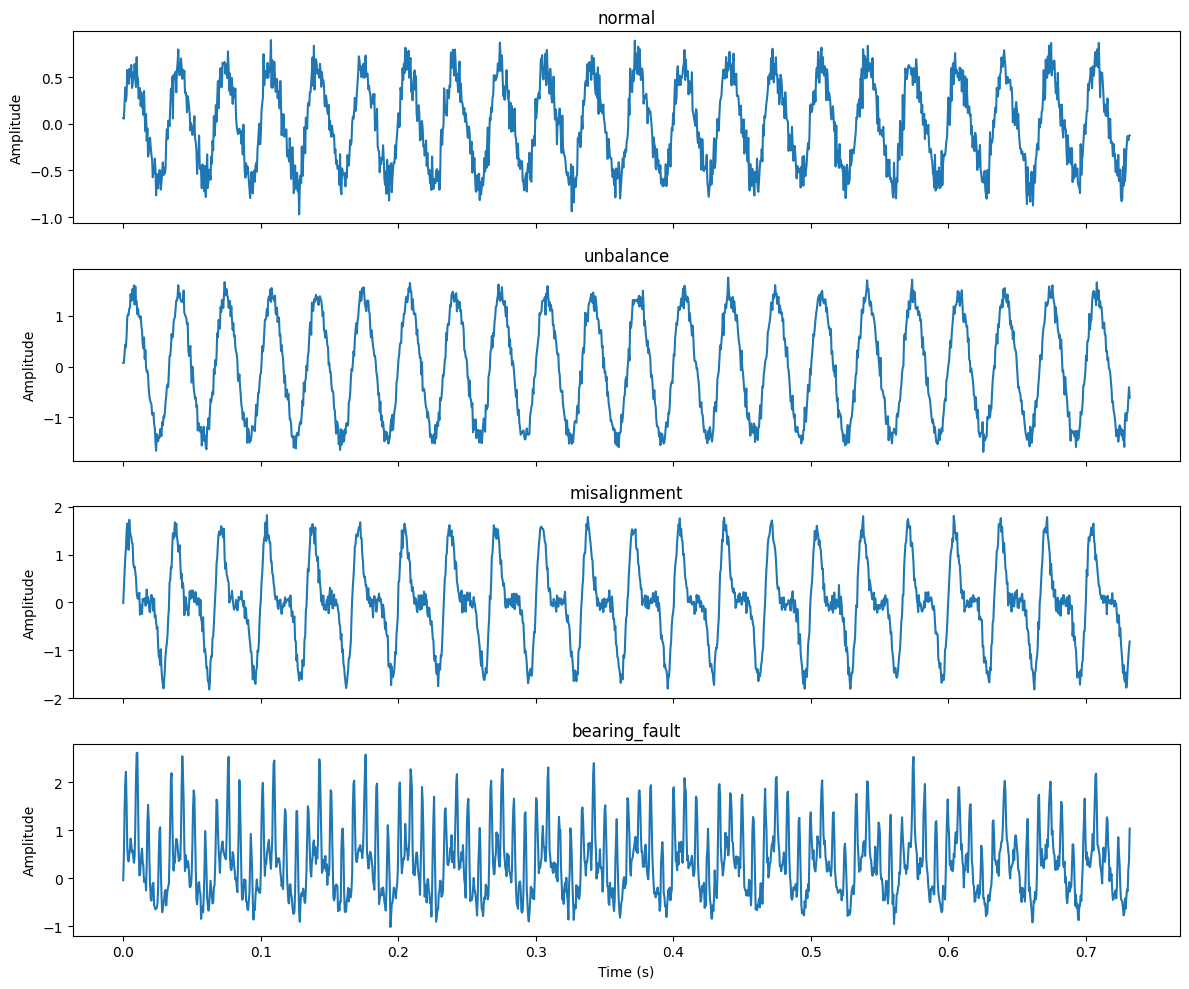

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, (label, sig) in zip(axes, signals.items()):
    ax.plot(TIME[:1500], sig[:1500])
    ax.set_title(label)
    ax.set_ylabel("Amplitude")
axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## 5. FFT 스펙트럼 비교

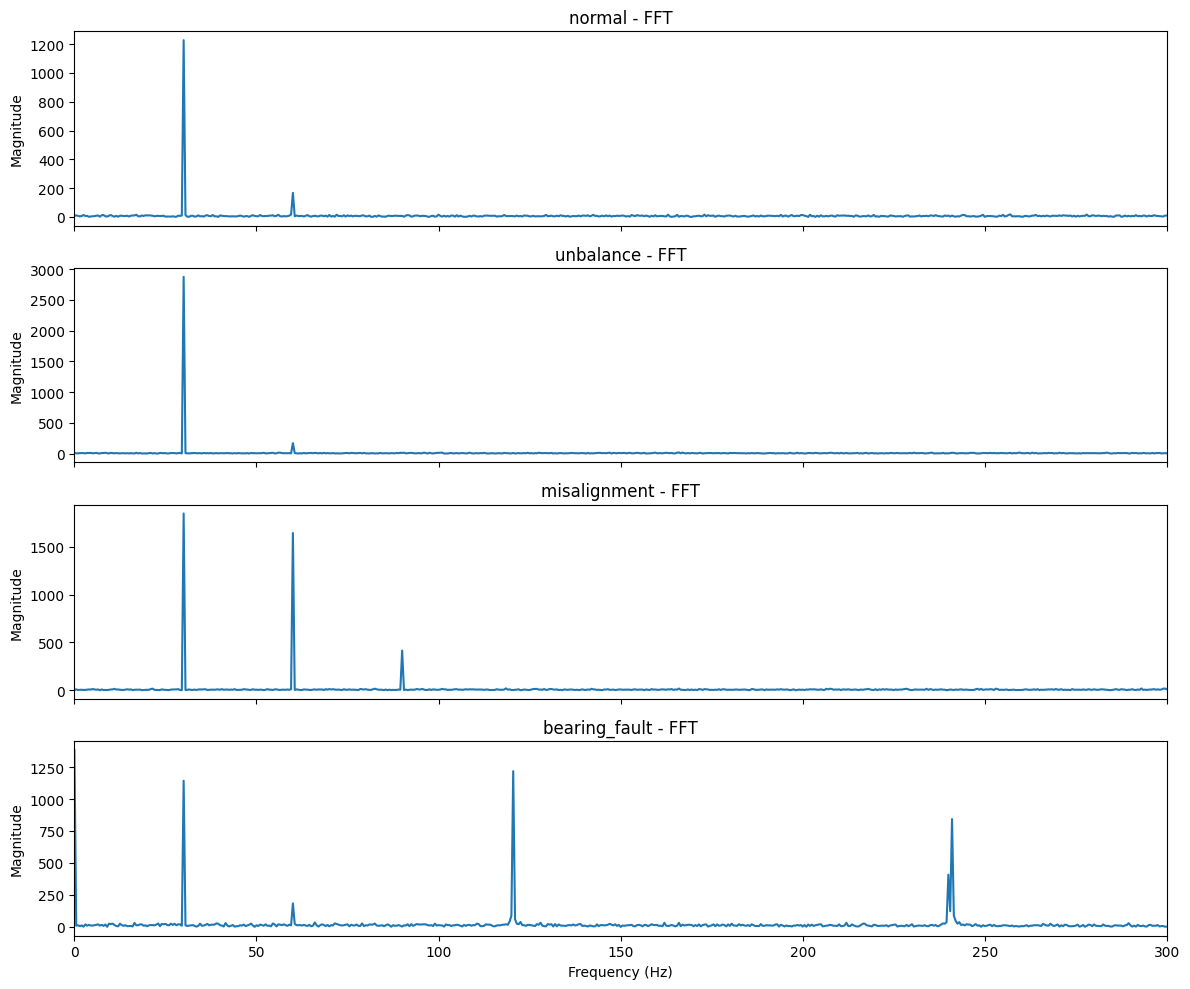

In [6]:
def compute_fft(signal, sampling_rate=SAMPLING_RATE):
    n = len(signal)
    xf = rfftfreq(n, 1 / sampling_rate)
    yf = np.abs(rfft(signal))
    return xf, yf

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, (label, sig) in zip(axes, signals.items()):
    xf, yf = compute_fft(sig)
    ax.plot(xf, yf)
    ax.set_xlim(0, 300)
    ax.set_title(f"{label} - FFT")
    ax.set_ylabel("Magnitude")
axes[-1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

## 6. 특징량 추출 함수 만들기

In [7]:
def rms(x):
    return np.sqrt(np.mean(np.square(x)))

def crest_factor(x):
    x_rms = rms(x)
    if x_rms == 0:
        return 0.0
    return np.max(np.abs(x)) / x_rms

def band_energy(xf, yf, low, high):
    mask = (xf >= low) & (xf < high)
    return float(np.sum(yf[mask] ** 2))

def extract_features(signal, sampling_rate=SAMPLING_RATE):
    xf, yf = compute_fft(signal, sampling_rate)
    dom_idx = np.argmax(yf[1:]) + 1 if len(yf) > 1 else 0
    dom_freq = xf[dom_idx] if len(xf) > dom_idx else 0.0

    low_band = band_energy(xf, yf, 0, 60)
    mid_band = band_energy(xf, yf, 60, 180)
    high_band = band_energy(xf, yf, 180, 500)
    total_band = low_band + mid_band + high_band + 1e-12

    return {
        "mean": float(np.mean(signal)),
        "std": float(np.std(signal)),
        "rms": float(rms(signal)),
        "max_abs": float(np.max(np.abs(signal))),
        "peak_to_peak": float(np.ptp(signal)),
        "kurtosis": float(kurtosis(signal)),
        "skewness": float(skew(signal)),
        "crest_factor": float(crest_factor(signal)),
        "dominant_freq": float(dom_freq),
        "spectral_energy": float(np.sum(yf ** 2)),
        "low_band_ratio": float(low_band / total_band),
        "mid_band_ratio": float(mid_band / total_band),
        "high_band_ratio": float(high_band / total_band),
    }

## 7. 샘플 1개씩 특징량 확인

In [8]:
sample_feature_df = pd.DataFrame(
    [extract_features(sig) for sig in signals.values()],
    index=signals.keys()
)
sample_feature_df.round(4)

,mean,std,rms,max_abs,peak_to_peak,kurtosis,skewness,crest_factor,dominant_freq,spectral_energy,low_band_ratio,mid_band_ratio,high_band_ratio
normal,0.0020,0.4443,0.4443,0.9712,1.8710,-1.2486,0.0008,2.1860,30.0,1.655884e+06,0.9508,0.0257,0.0235
unbalance,-0.0032,1.0023,1.0023,1.7526,3.5012,-1.4525,-0.0047,1.7486,30.0,8.427462e+06,0.9902,0.0053,0.0045
misalignment,-0.0003,0.8734,0.8734,1.8887,3.7405,-0.5223,0.0059,2.1625,30.0,6.398742e+06,0.5389,0.4549,0.0062
bearing_fault,0.3375,0.7057,0.7822,2.8661,3.9555,0.1408,0.7077,3.6641,120.5,6.088622e+06,0.5386,0.2624,0.1990


## 8. 윈도우 기반 데이터셋 만들기

실무에서는 긴 신호를 여러 개의 작은 구간(window)으로 나눈 뒤  
각 구간마다 특징량을 계산해서 모델 입력 데이터로 사용합니다.

In [9]:
def window_signal(signal, window_size=1024, step_size=512):
    windows = []
    for start in range(0, len(signal) - window_size + 1, step_size):
        windows.append(signal[start:start+window_size])
    return windows

def generate_dataset(n_samples_per_class=120):
    rows = []

    generators = {
        "normal": generate_normal_signal,
        "unbalance": generate_unbalance_signal,
        "misalignment": generate_misalignment_signal,
        "bearing_fault": generate_bearing_fault_signal,
    }

    for label, gen_fn in generators.items():
        for _ in range(n_samples_per_class):
            sig = gen_fn(TIME)
            windows = window_signal(sig, window_size=1024, step_size=1024)
            # 신호당 여러 윈도우가 나오지만, 여기서는 간단히 첫 윈도우만 사용
            w = windows[0]
            feat = extract_features(w)
            feat["label"] = label
            rows.append(feat)

    return pd.DataFrame(rows)

df = generate_dataset(n_samples_per_class=150)
df.head()

,mean,std,rms,max_abs,peak_to_peak,kurtosis,skewness,crest_factor,dominant_freq,spectral_energy,low_band_ratio,mid_band_ratio,high_band_ratio,label
0,0.004879,0.444762,0.444789,0.909175,1.783190,-1.240029,-0.033772,2.044060,30.0,103736.669671,0.950991,0.027352,0.021657,normal
1,0.005150,0.441815,0.441845,0.943899,1.859477,-1.281617,0.004443,2.136269,30.0,102369.597292,0.950834,0.024579,0.024586,normal
2,-0.002149,0.443425,0.443430,0.987367,1.903308,-1.241773,-0.006351,2.226658,30.0,103099.209698,0.951541,0.024189,0.024269,normal
3,0.003544,0.446716,0.446730,0.863999,1.713033,-1.264991,0.011252,1.934053,30.0,104637.465191,0.954269,0.024785,0.020946,normal
4,0.006170,0.440739,0.440782,1.093334,1.933102,-1.239213,0.026814,2.480439,30.0,101884.202153,0.946976,0.029509,0.023515,normal


In [10]:
print(df.shape)
df["label"].value_counts()

(600, 14)


label
normal           150
unbalance        150
misalignment     150
bearing_fault    150
Name: count, dtype: int64

## 9. 클래스별 특징량 평균 비교

In [11]:
class_means = df.groupby("label").mean(numeric_only=True)
class_means.round(4)

,mean,std,rms,max_abs,peak_to_peak,kurtosis,skewness,crest_factor,dominant_freq,spectral_energy,low_band_ratio,mid_band_ratio,high_band_ratio
label,,,,,,,,,,,,,
bearing_fault,0.3320,0.7337,0.8053,2.6314,3.6213,0.0476,0.7426,3.2679,50.4,397922.1006,0.4997,0.2466,0.2537
misalignment,0.0001,0.8710,0.8710,1.8710,3.6791,-0.5205,0.0005,2.1482,30.0,397743.7424,0.5394,0.4546,0.0060
normal,-0.0003,0.4442,0.4442,0.9473,1.8407,-1.2441,0.0001,2.1324,30.0,103478.2107,0.9505,0.0259,0.0236
unbalance,-0.0003,0.9992,0.9992,1.7134,3.3731,-1.4487,0.0000,1.7148,30.0,523452.7798,0.9905,0.0050,0.0045


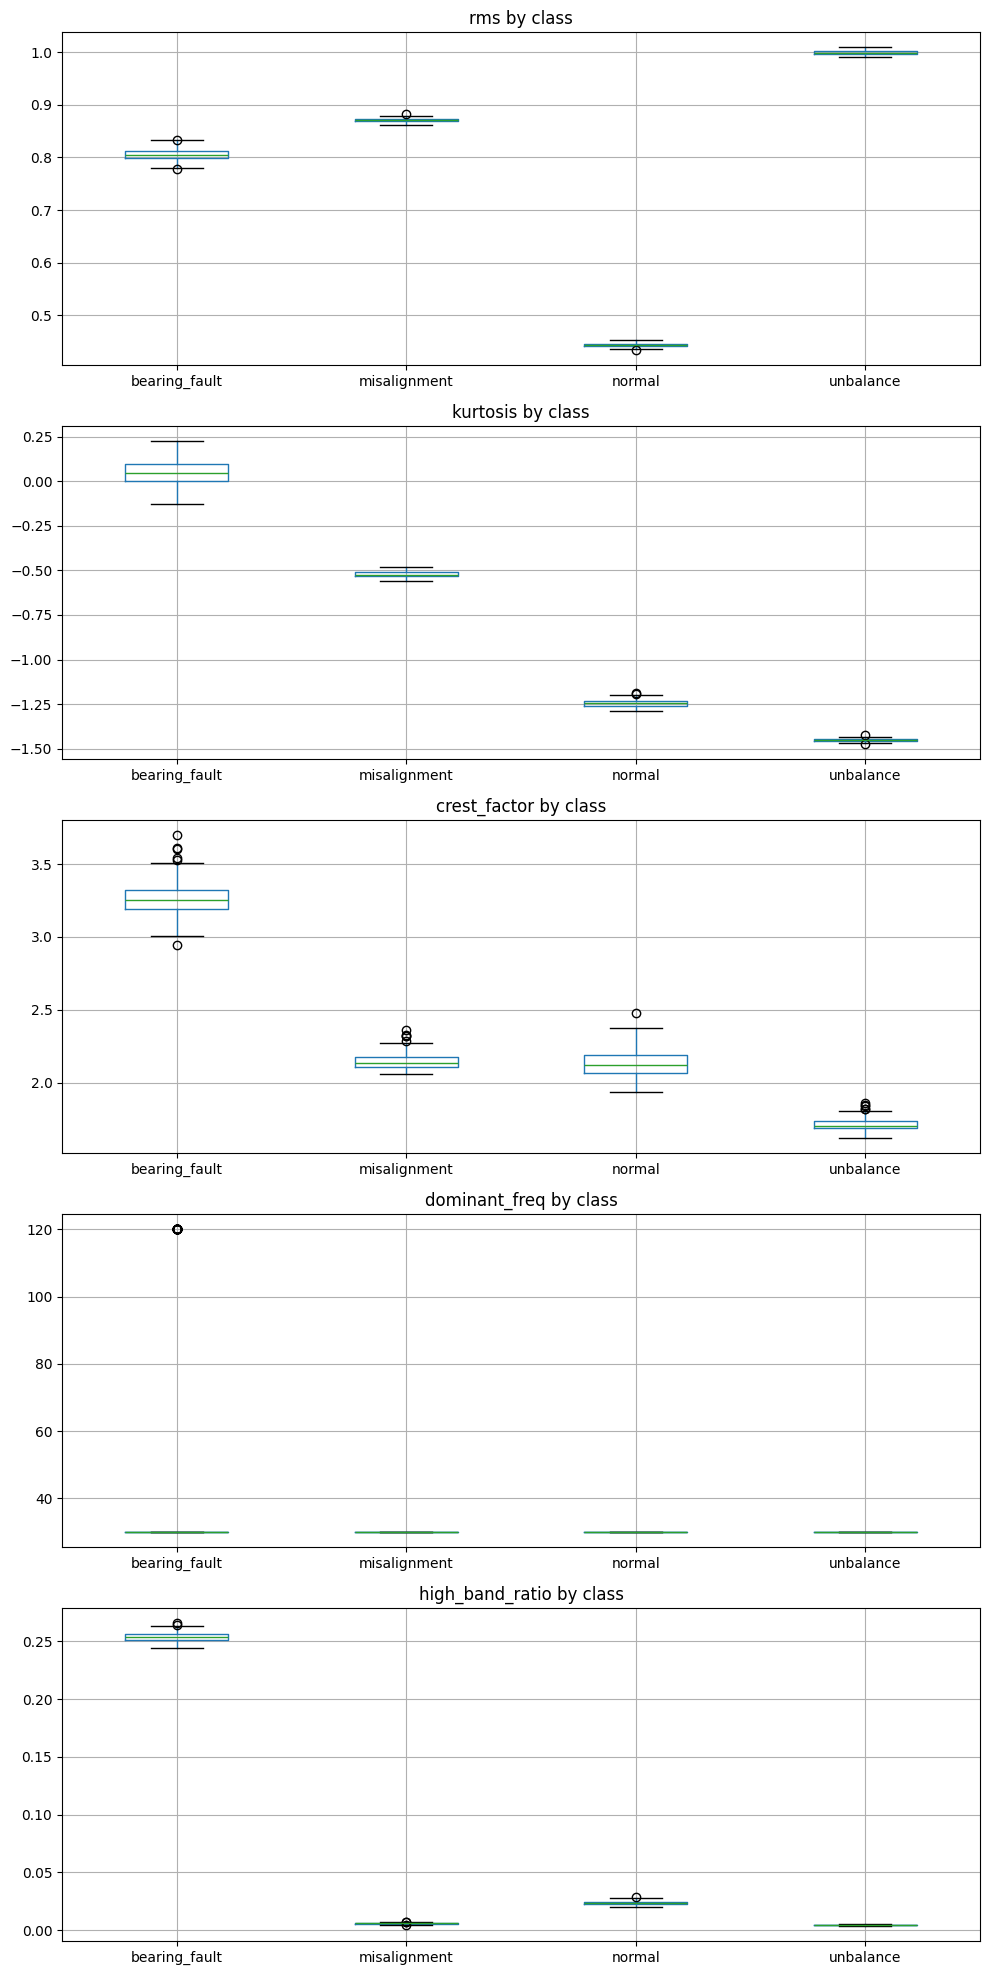

In [12]:
selected_cols = ["rms", "kurtosis", "crest_factor", "dominant_freq", "high_band_ratio"]

fig, axes = plt.subplots(len(selected_cols), 1, figsize=(10, 4 * len(selected_cols)))
for ax, col in zip(axes, selected_cols):
    df.boxplot(column=col, by="label", ax=ax)
    ax.set_title(f"{col} by class")
    ax.set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

### 관찰 포인트
- **Unbalance**: RMS가 커지고 저주파/1X 영향이 두드러질 수 있음
- **Misalignment**: 2X 영향 때문에 주파수 성분 구조가 달라질 수 있음
- **Bearing Fault**: Kurtosis, Crest Factor, 고주파 대역 비율이 상대적으로 커질 수 있음

## 10. 간단한 분류 모델 학습

가상 데이터이지만, 특징량만으로도 고장 유형을 어느 정도 분류할 수 있는지 확인합니다.

In [13]:
feature_cols = [c for c in df.columns if c != "label"]
X = df[feature_cols]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

clf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

bearing_fault       1.00      1.00      1.00        38
 misalignment       1.00      1.00      1.00        37
       normal       1.00      1.00      1.00        38
    unbalance       1.00      1.00      1.00        37

     accuracy                           1.00       150
    macro avg       1.00      1.00      1.00       150
 weighted avg       1.00      1.00      1.00       150



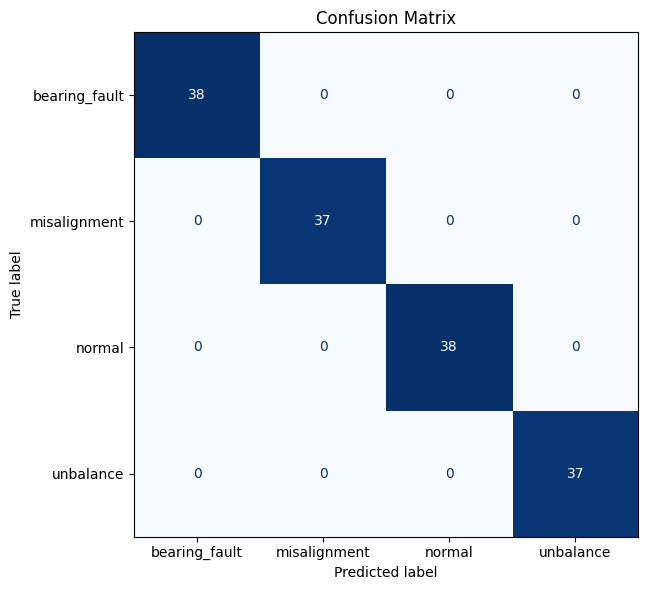

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## 11. Feature Importance 확인

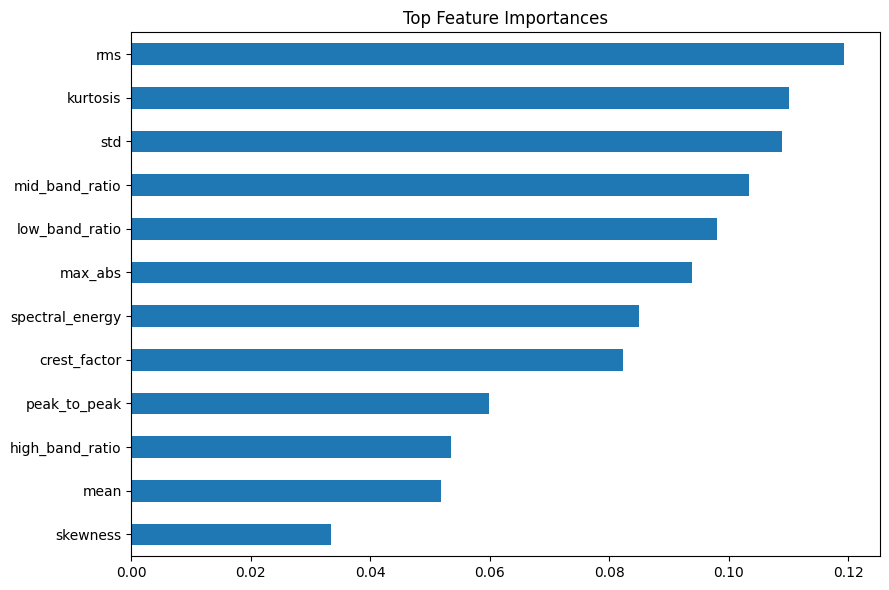

rms                0.1194
kurtosis           0.1100
std                0.1090
mid_band_ratio     0.1035
low_band_ratio     0.0981
max_abs            0.0939
spectral_energy    0.0850
crest_factor       0.0824
peak_to_peak       0.0599
high_band_ratio    0.0535
mean               0.0518
skewness           0.0335
dtype: float64

In [15]:
importances = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
importances.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances")
plt.tight_layout()
plt.show()

importances.head(12).round(4)

## 실제 프로젝트로 확장하려면
- 실제 센서/진동 로그 사용
- 더 짧은/긴 윈도우 비교
- 시간 순서 기반 검증
- FFT band power 세분화
- 실제 베어링 결함 주파수(BPFO, BPFI 등) 반영
- 이상탐지(anomaly detection) 방식 추가